#Ingénierie des variables de comportement

In [35]:
import pandas as pd
import os

# Chemin identifié d'après la liste des fichiers
drive_path = '/content/gdrive/MyDrive/Time series Projet/data'

try:
    # Importation des fichiers
    hotel_bookings = pd.read_csv(os.path.join(drive_path, 'hotel_bookings_clean.csv'))
    hospitality_benchmark = pd.read_csv(os.path.join(drive_path, 'hospitality_benchmark_clean.csv'))

    print('\nAperçu de hotel_bookings_clean :')
    display(hotel_bookings.head())

    print('\nAperçu de hospitality_benchmark_clean :')
    display(hospitality_benchmark.head())
except FileNotFoundError:
    print(f'Erreur : Fichiers non trouvés dans {drive_path}.')
    print('Contenu du dossier :', os.listdir(drive_path) if os.path.exists(drive_path) else 'Dossier introuvable')


Aperçu de hotel_bookings_clean :


,date,adr_mean,occupancy_rate,total_revenue,avg_stay,cancel_rate
0,2015-07-01,95.169160,0.840336,28404.76,3.176471,0.159664
1,2015-07-02,82.205484,0.387097,19614.45,3.935484,0.612903
2,2015-07-03,97.183036,0.660714,15756.98,4.285714,0.339286
3,2015-07-04,86.565977,0.505747,21583.04,5.034483,0.494253
4,2015-07-05,100.002642,0.698113,23756.85,5.962264,0.301887



Aperçu de hospitality_benchmark_clean :


,Country,date,occupancy,revenue_usd,nb_hotels,avg_stay,satisfaction
0,Italy,2022-02-01,79.0,227923.45,70,12.4,9.7
1,India,2020-03-01,70.6,181346.52,302,14.9,6.9
2,Japan,2022-04-01,74.0,356355.85,378,8.1,8.4
3,United Kingdom,2021-01-01,49.1,362715.68,437,4.3,9.6
4,Egypt,2022-12-01,59.4,277682.65,387,2.6,8.9


In [36]:
from google.colab import drive
drive.mount('/content/gdrive')


Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


### Transformer en donner

Pour hotel bookings

In [37]:
# Transformer les données de hotel_bookings en données mensuelles
import pandas as pd

# S'assurer que la colonne date est au format datetime
hotel_bookings['date'] = pd.to_datetime(hotel_bookings['date'])

# Utilisation de 'ME' (Month End) pour le rééchantillonnage afin d'éviter les avertissements de dépréciation
hotel_bookings_monthly = hotel_bookings.set_index('date').resample('ME').mean().reset_index()

print('Aperçu des données mensuelles de hotel_bookings :')
display(hotel_bookings_monthly.head())

Aperçu des données mensuelles de hotel_bookings :


,date,adr_mean,occupancy_rate,total_revenue,avg_stay,cancel_rate
0,2015-07-31,103.569739,0.568210,24462.573871,4.223812,0.431790
1,2015-08-31,112.599862,0.622200,36698.474516,3.918691,0.377800
2,2015-09-30,96.761903,0.620468,35154.022333,3.657870,0.379532
3,2015-10-31,79.953368,0.689992,25313.383226,3.149414,0.310008
4,2015-11-30,61.991563,0.798815,11556.983000,3.360779,0.201185


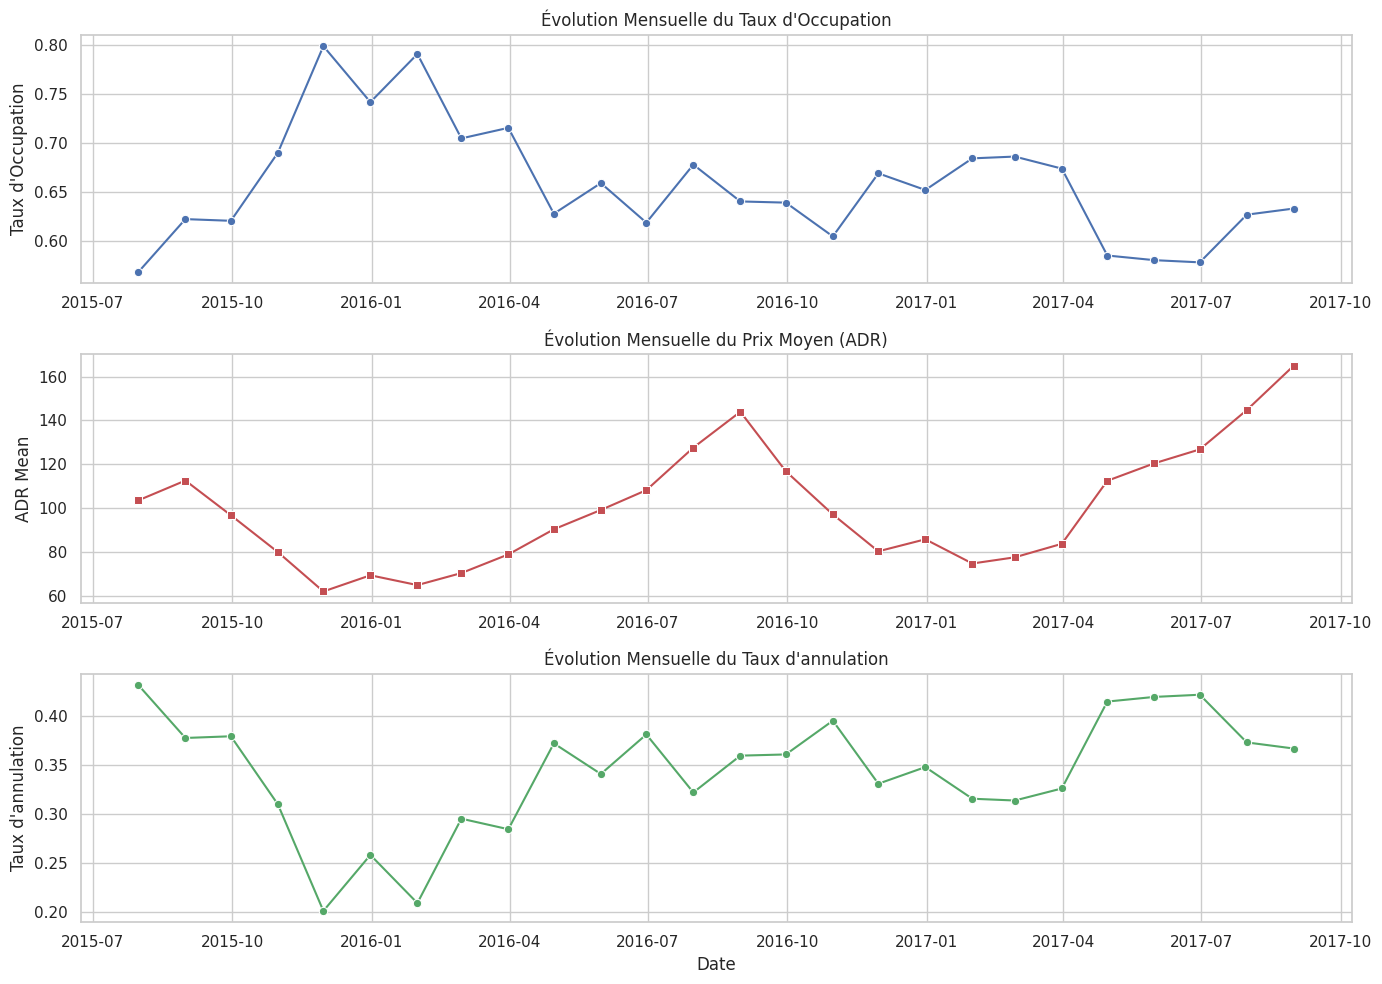

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration du style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 10))

# Tracer l'évolution du taux d'occupation
plt.subplot(3, 1, 1)
sns.lineplot(data=hotel_bookings_monthly, x='date', y='occupancy_rate', marker='o', color='b')
plt.title('Évolution Mensuelle du Taux d\'Occupation')
plt.xlabel('')
plt.ylabel('Taux d\'Occupation')

# Tracer l'évolution du prix moyen (ADR)
plt.subplot(3, 1, 2)
sns.lineplot(data=hotel_bookings_monthly, x='date', y='adr_mean', marker='s', color='r')
plt.title('Évolution Mensuelle du Prix Moyen (ADR)')
plt.xlabel('')
plt.ylabel('ADR Mean')

# Tracer l'évolution du taux d'annulation
plt.subplot(3, 1, 3)
sns.lineplot(data=hotel_bookings_monthly, x='date', y='cancel_rate', marker='o', color='g')
plt.title('Évolution Mensuelle du Taux d\'annulation')
plt.xlabel('Date')
plt.ylabel('Taux d\'annulation')

plt.tight_layout()
plt.show()

In [39]:
# Chercher les outliers
def flag_outliers(series, label):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    low, high = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    mask = (series < low) | (series > high)
    print(f"{label}: {mask.sum()} outliers ({mask.mean() * 100:.1f}%)")
    return mask

print("\n--- Outlier count (IQR 1.5x) ---")
# Liste des colonnes présentes dans hotel_bookings_monthly
cols_to_check = ['adr_mean', 'occupancy_rate', 'total_revenue', 'avg_stay', 'cancel_rate']

for col in cols_to_check:
    if col in hotel_bookings_monthly.columns:
        flag_outliers(hotel_bookings_monthly[col], col)


--- Outlier count (IQR 1.5x) ---
adr_mean: 0 outliers (0.0%)
occupancy_rate: 2 outliers (7.7%)
total_revenue: 0 outliers (0.0%)
avg_stay: 0 outliers (0.0%)
cancel_rate: 2 outliers (7.7%)


In [40]:
from scipy import stats

# Test de normalité
print("\n--- Normality tests (Shapiro-Wilk) ---")

# Liste des colonnes à tester (nettoyage des espaces dans les noms)
cols_to_test = ['adr_mean', 'occupancy_rate', 'cancel_rate']

for col in cols_to_test:
    if col in hotel_bookings_monthly.columns:
        # On retire les NaN pour le test
        sample = hotel_bookings_monthly[col].dropna().values

        # Test de Shapiro-Wilk
        stat, p = stats.shapiro(sample)

        status = "Normal OK" if p > 0.05 else "NOT normal"
        print(f"{col:15} : p={p:.4f} -> {status}")


--- Normality tests (Shapiro-Wilk) ---
adr_mean        : p=0.2176 -> Normal OK
occupancy_rate  : p=0.1707 -> Normal OK
cancel_rate     : p=0.1707 -> Normal OK


In [41]:
# Création de la colonne 'month' pour le groupement
hotel_bookings_monthly['month'] = hotel_bookings_monthly['date'].dt.month

# Calcul du profil saisonnier
seasonal = hotel_bookings_monthly.groupby('month').agg(
    occ_mean=('occupancy_rate', 'mean'),
    occ_std=('occupancy_rate', 'std'),
    adr_mean=('adr_mean', 'mean'),
    cancel_mean=('cancel_rate', 'mean')
).reset_index()

# Normalisation de la courbe d'occupation [0, 1]
seasonal['occ_index'] = (seasonal['occ_mean'] - seasonal['occ_mean'].min()) / \
                         (seasonal['occ_mean'].max() - seasonal['occ_mean'].min())

# ADR premium = déviation par rapport à la moyenne annuelle
seasonal['adr_premium'] = (seasonal['adr_mean'] / seasonal['adr_mean'].mean() - 1) * 100

print("\n--- Seasonal profile (by month) ---")
print(seasonal[['month', 'occ_mean', 'occ_index', 'adr_premium', 'cancel_mean']].to_string())


--- Seasonal profile (by month) ---
    month  occ_mean  occ_index  adr_premium  cancel_mean
0       1  0.737499   1.000000   -28.001095     0.262501
1       2  0.695331   0.697004   -23.718098     0.304669
2       3  0.694579   0.691597   -16.152007     0.305421
3       4  0.606370   0.057781     4.576613     0.393630
4       5  0.619637   0.153108    13.230685     0.380363
5       6  0.598329   0.000000    21.167969     0.401671
6       7  0.624263   0.186347    29.209522     0.375737
7       8  0.631813   0.240602    44.904957     0.368187
8       9  0.629747   0.225754    10.117863     0.370253
9      10  0.647268   0.351648    -8.698644     0.352732
10     11  0.733869   0.973912   -26.636814     0.266131
11     12  0.696793   0.707509   -20.000953     0.303207


In [51]:
# Correction du nom de fichier et du print
seasonal.to_csv('hotel_seasonal_profile.csv', index=False)
print("Seasonal profile saved -> hotel_seasonal_profile.csv")

Seasonal profile saved -> hotel_seasonal_profile.csv


pour hospitality_benchmark


In [43]:
# Correction : Utilisation du bon nom de variable et suppression des espaces dans les noms de colonnes
hospitality_benchmark = hospitality_benchmark.sort_values(['Country', 'date']).reset_index(drop=True)

print("Données de benchmark triées par pays et par date.")
display(hospitality_benchmark.head())

Données de benchmark triées par pays et par date.


,Country,date,occupancy,revenue_usd,nb_hotels,avg_stay,satisfaction
0,Australia,2020-02-01,87.2,305193.39,395,13.7,5.1
1,Australia,2020-07-01,85.9,34185.35,172,7.1,5.3
2,Australia,2020-09-01,67.3,672396.26,380,2.7,7.0
3,Australia,2020-12-01,66.6,243365.26,157,11.6,5.5
4,Australia,2021-05-01,89.1,162792.43,451,5.7,9.7


In [44]:
# Correction des noms de pays et suppression des numéros de ligne
COMPARABLE = ['Egypt', 'Turkey', 'Spain', 'France', 'UAE', 'United Arab Emirates', 'Greece']

# Filtrage en utilisant le bon nom de variable (hospitality_benchmark)
# Nous utilisons .str.strip() par sécurité au cas où il resterait des espaces
bench_comp = hospitality_benchmark[hospitality_benchmark['Country'].str.strip().isin(COMPARABLE)].copy()

print(f"Nombre de lignes après filtrage : {len(bench_comp)}")
display(bench_comp.head())

Nombre de lignes après filtrage : 126


,Country,date,occupancy,revenue_usd,nb_hotels,avg_stay,satisfaction
117,Egypt,2020-06-01,77.6,575572.80,377,6.3,8.2
118,Egypt,2020-09-01,70.2,661991.77,254,11.2,8.2
119,Egypt,2020-10-01,71.3,200893.73,336,7.8,6.8
120,Egypt,2020-11-01,84.0,407240.16,464,8.8,9.1
121,Egypt,2021-01-01,79.3,230942.18,397,3.5,7.7


In [45]:
# S'assurer que la colonne date est au format datetime
bench_comp['date'] = pd.to_datetime(bench_comp['date'])

# Calcul de la baseline pré-covid (moyenne avant fév 2020)
pre_covid = bench_comp[bench_comp['date'] <= '2020-02-01'].groupby('Country')['occupancy'].mean().rename('baseline_occ')

# Fusion avec les données originales
bench_comp = bench_comp.merge(pre_covid.reset_index(), on='Country')

# Calcul du ratio de récupération
bench_comp['occ_recovery_ratio'] = bench_comp['occupancy'] / bench_comp['baseline_occ']

print("--- Recovery ratio by country (mean 2022) ---")
# Filtrage pour l'année 2022
recovery_2022 = bench_comp[bench_comp['date'].dt.year == 2022].groupby('Country')['occ_recovery_ratio'].mean().sort_values(ascending=False)

print(recovery_2022.round(3).to_string())

--- Recovery ratio by country (mean 2022) ---
Country
Greece                  1.863
United Arab Emirates    1.278
Turkey                  0.991
Spain                   0.836


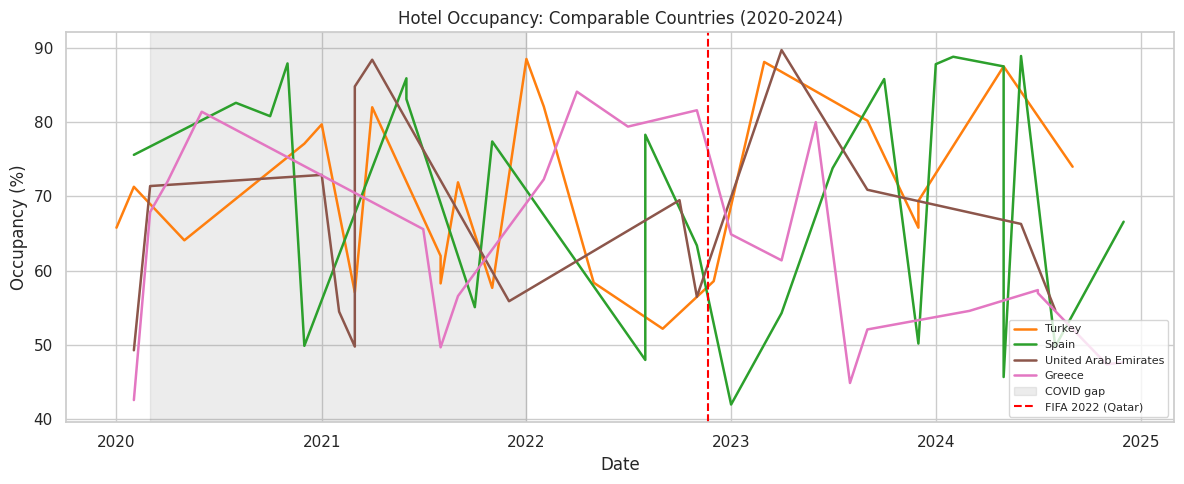

In [46]:
import matplotlib.pyplot as plt
import pandas as pd

# Correction : Initialisation de la figure et utilisation de bench_comp
fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.tab10(range(len(COMPARABLE)))

for i, country in enumerate(COMPARABLE):
    # On nettoie les espaces éventuels dans 'Country' pour le filtrage
    subset = bench_comp[bench_comp['Country'].str.strip() == country.strip()].sort_values('date')

    if len(subset) == 0: continue

    ax.plot(subset['date'], subset['occupancy'],
            label=country, lw=1.8, color=colors[i])

# Zones indicatives
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2022-01-01'),
           alpha=0.15, color='gray', label='COVID gap')
ax.axvline(pd.Timestamp('2022-11-20'), ls='--', color='red',
           lw=1.5, label='FIFA 2022 (Qatar)')

ax.set(xlabel='Date', ylabel='Occupancy (%)',
       title='Hotel Occupancy: Comparable Countries (2020-2024)')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('benchmark_occupancy.pdf', dpi=150, bbox_inches='tight')
plt.show()

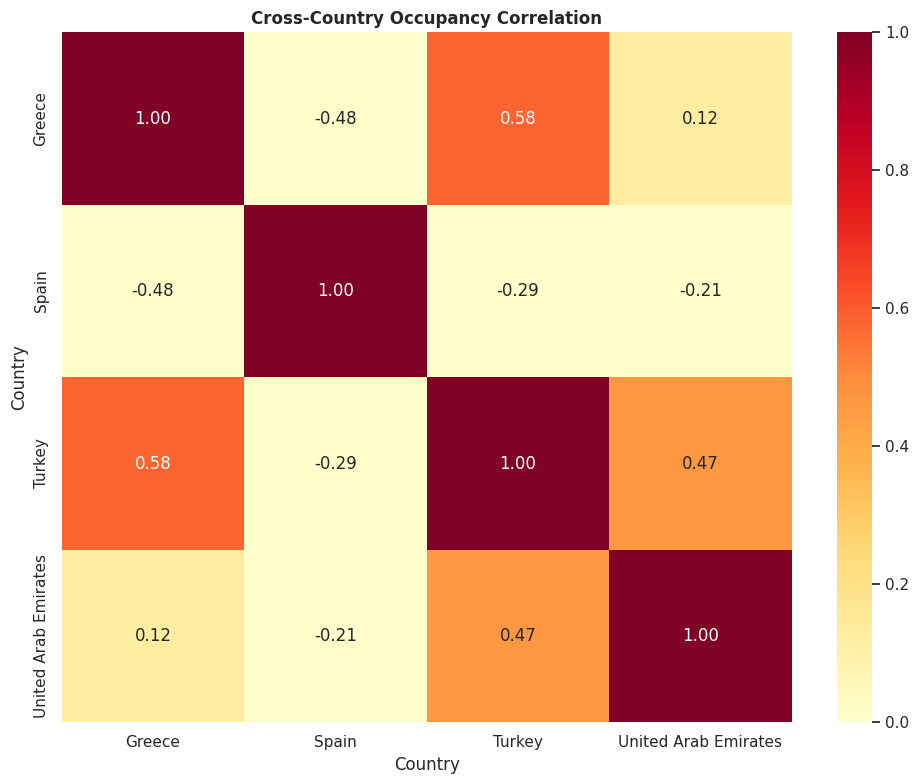


Satisfaction ~ Occupancy: slope=-0.0050, R=-0.050, p=6.5968e-01

Données mensuelles agrégées pour l'imputation (bench_comp_monthly) créées.


,date,occ_bench,revenue_bench,recovery_ratio,satisfaction
0,2020-01-01,65.80,568041.740,0.959883,6.5
1,2020-02-01,73.45,498961.925,1.020058,7.0
2,2020-05-01,64.10,946879.950,0.935084,6.0
3,2020-08-01,82.60,95590.350,1.092593,8.9
4,2020-10-01,80.80,548010.580,1.068783,7.0


In [47]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ---- 5. Cross-Country Correlation ----
# On pivote les données pour avoir les pays en colonnes
bench_pivot = bench_comp.pivot_table(index='date', columns='Country', values='occupancy', aggfunc='mean')
corr_matrix = bench_pivot.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, vmin=0, vmax=1)
ax.set_title('Cross-Country Occupancy Correlation', fontweight='bold')
plt.tight_layout()
plt.savefig('benchmark_corr.pdf', dpi=150, bbox_inches='tight')
plt.show()

# ---- 6. Satisfaction vs. occupancy regression ----
# Suppression des NaN pour la régression
valid_data = bench_comp.dropna(subset=['occupancy', 'satisfaction'])
slope, intercept, r, p, se = linregress(valid_data['occupancy'], valid_data['satisfaction'])
print(f"\nSatisfaction ~ Occupancy: slope={slope:.4f}, R={r:.3f}, p={p:.4e}")

# ---- 7. Export comparable benchmark for imputation ----
# Agrégation mensuelle pour les pays de référence
bench_comp_monthly = bench_comp[bench_comp['Country'].str.strip().isin(['Egypt', 'Turkey', 'Spain'])].groupby('date').agg(
    occ_bench=('occupancy', 'mean'),
    revenue_bench=('revenue_usd', 'mean'),
    recovery_ratio=('occ_recovery_ratio', 'mean'),
    satisfaction=('satisfaction', 'mean')
).reset_index()

print("\nDonnées mensuelles agrégées pour l'imputation (bench_comp_monthly) créées.")
display(bench_comp_monthly.head())

In [50]:
# Export des données mensuelles agrégées
bench_comp_monthly.to_csv('benchmark_comparable.csv', index=False)
print("\nBenchmark export saved -> benchmark_comparable.csv")


Benchmark export saved -> benchmark_comparable.csv
